<a href="https://colab.research.google.com/github/AnaSantillanal246102/DataScience/blob/main/Procesamiento_Datos/Equipa3_DesercionEscolar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**<h1>Deserción escolar:📉📚😔</h1>**

## **Introducción al Proyecto**


---


El objetivo principal del proyecto es identificar, analizar y comprender los factores que inciden en la deserción estudiantil en los distintos niveles educativos, especialmente en contextos marcados por desigualdad socioeconómica y falta de acompañamiento académico o emocional. El proyecto busca generar información útil para prevenir el abandono escolar, promover la retención estudiantil y diseñar estrategias efectivas de intervención educativa.

A través del análisis de datos socioeconómicos, familiares, académicos y demográficos, se pretende establecer relaciones significativas entre estos factores y la decisión de los estudiantes de abandonar sus estudios. Esta comprensión permitirá apoyar a los tomadores de decisiones en la creación de políticas educativas más justas, inclusivas y efectivas.

📚**Preguntas Clave**
1.   ¿Cuáles son los principales factores (socioeconómicos, familiares, demográficos) que explican el abandono escolar y cómo varían según el perfil del estudiante?
2.   ¿Qué influencia tienen los factores académicos y emocionales (rendimiento, nivel educativo parental, acompañamiento) en la decisión de continuar o desertar?
3.  ¿Qué tan efectivas han sido las estrategias de intervención existentes (becas, tutorías, apoyo tecnológico) en la reducción de la deserción, y cómo responden a ellas los distintos segmentos de la población?
4.  ¿Qué características de la oferta educativa (modalidades, costos,
carreras) y la percepción de oportunidades laborales o académicas influyen en la elección y permanencia de los estudiantes?

**📉Información de los Datasets:**
1. [Education Inequality Data](https://www.kaggle.com/datasets/shamimhasan8/education-inequality-data)

    link: https://www.kaggle.com/datasets/shamimhasan8/education-inequality-data

2. [Deserción Escolar Bogotá Factores De Riesgo](https://www.kaggle.com/datasets/uhbyguvyuhvb555/desercin-escolar-bogot-factores-de-riesgo)

    link: https://www.kaggle.com/datasets/uhbyguvyuhvb555/desercin-escolar-bogot-factores-de-riesgo

## **Preparación del Entorno**
Antes de comenzar con nuestros dataset exportamos las librerias que usaremos en este análisis.

---



In [ ]:
pip install kagglehub[pandas-datasets]

In [ ]:

import pandas as pd               # Pandas sirve para la manipulación de las tablas
import matplotlib.pyplot as plt   # Matplotlib.pyplot nos ayuda a generar gráficos
import seaborn as sns             # Seaborn nos ayuda a mostrar los datos.
import numpy as np
import kagglehub

sns.set_style("whitegrid")        # Ayuda a mejorar el estilo, el fondo lo coloca en color blanco y coloca las líneas en color gris.


## **Cargar los dataset**
En esta sección cargamos los dataset que usaremos, en esta ocasión cargamos uno desde una dirección en nuestro drive y otro directamente desde Kaggle atraves del API de la misma.


---



In [ ]:
df_inequality = pd.read_csv('https://drive.google.com/uc?export=download&id=1-QMHjDqfBLkPtdYwgx09y5wbYaOhV5uY')     # Carga el archivo dataframe(df) llamado education_inequality_data.csv
df_inequality.head()

,id,school_name,state,school_type,grade_level,funding_per_student_usd,avg_test_score_percent,student_teacher_ratio,percent_low_income,percent_minority,internet_access_percent,dropout_rate_percent
0,1,Bowman High School,Michigan,Private,High,9575.80,65.9,17.5,30.0,44.0,74.1,3.44
1,2,Foster High School,Michigan,Charter,Middle,16733.10,87.3,24.2,93.5,40.1,79.9,8.67
2,3,Henson High School,New York,Public,Middle,24890.74,72.8,27.0,58.1,35.8,51.1,14.75
3,4,Weaver High School,Texas,Private,Elementary,6857.49,81.5,26.2,82.7,72.0,55.5,13.45
4,5,King Elementary School,Michigan,Public,Elementary,16910.73,44.7,20.2,41.4,16.1,57.8,6.98


In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "datos_desercion.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "uhbyguvyuhvb555/desercin-escolar-bogot-factores-de-riesgo",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)
df_desercion = pd.DataFrame( df)
df_desercion.head()

/tmp/ipython-input-1761372089.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 6.13k/6.13k [00:00<00:00, 9.38MB/s]


,Estudiante ID,Localidad,Edad,Ingreso Familiar (COP),Nivel Educativo Padre (años),Nivel Educativo Madre (años),Acceso a Internet,Número Integrantes Hogar,Desempleo en el Hogar (%),Violencia Intrafamiliar,Deserción Escolar
0,1,Ciudad Bolívar,14,1000000,9,8.0,1.0,6.0,15.0,0.0,1.0
1,2,Bosa,13,1200000,11,10.0,0.0,5.0,18.0,1.0,0.0
2,3,San Cristóbal,16,800000,7,6.0,1.0,7.0,20.0,1.0,1.0
3,4,Usme,15,1300000,10,9.0,0.0,5.0,18.0,0.0,1.0
4,5,Kennedy,12,1800000,13,12.0,0.0,4.0,14.0,1.0,0.0


##**Observación de los dataset**
Realizamos una breve observaación de los dataset para conocer los procesos que usaremos para la preparación y limpieza de datos.


---



In [ ]:
df_inequality.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       1000 non-null   int64  
 1   school_name              1000 non-null   object 
 2   state                    1000 non-null   object 
 3   school_type              1000 non-null   object 
 4   grade_level              1000 non-null   object 
 5   funding_per_student_usd  1000 non-null   float64
 6   avg_test_score_percent   1000 non-null   float64
 7   student_teacher_ratio    1000 non-null   float64
 8   percent_low_income       1000 non-null   float64
 9   percent_minority         1000 non-null   float64
 10  internet_access_percent  1000 non-null   float64
 11  dropout_rate_percent     1000 non-null   float64
dtypes: float64(7), int64(1), object(4)
memory usage: 93.9+ KB


In [ ]:
df_desercion.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Estudiante ID                 150 non-null    int64  
 1   Localidad                     150 non-null    object 
 2   Edad                          150 non-null    int64  
 3   Ingreso Familiar (COP)        150 non-null    int64  
 4   Nivel Educativo Padre (años)  150 non-null    int64  
 5   Nivel Educativo Madre (años)  149 non-null    float64
 6   Acceso a Internet             149 non-null    float64
 7   Número Integrantes Hogar      149 non-null    float64
 8   Desempleo en el Hogar (%)     149 non-null    float64
 9   Violencia Intrafamiliar       149 non-null    float64
 10  Deserción Escolar             149 non-null    float64
dtypes: float64(6), int64(4), object(1)
memory usage: 13.0+ KB


Este primer comando nos permite revisar puntos claves de nuestro dataset:


*   Tipos de datos
*   El número de registros
*   Columnas con valores Nulos



In [ ]:
df_inequality.describe()

,id,funding_per_student_usd,avg_test_score_percent,student_teacher_ratio,percent_low_income,percent_minority,internet_access_percent,dropout_rate_percent
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,15154.160180,70.001000,19.733200,53.756400,49.652000,74.688500,7.765600
std,288.819436,5931.384208,17.703408,5.823201,24.021689,25.241025,14.433086,4.214452
min,1.000000,5012.970000,40.000000,10.000000,10.200000,5.000000,50.000000,0.500000
25%,250.750000,9726.040000,54.575000,14.800000,33.400000,29.300000,62.400000,4.050000
50%,500.500000,15362.465000,69.900000,19.400000,54.100000,49.450000,74.750000,7.685000
75%,750.250000,20280.007500,85.625000,25.000000,74.600000,69.950000,87.325000,11.492500
max,1000.000000,24981.900000,100.000000,30.000000,94.900000,94.900000,100.000000,14.990000


In [ ]:
df_desercion.describe()

,Estudiante ID,Edad,Ingreso Familiar (COP),Nivel Educativo Padre (años),Nivel Educativo Madre (años),Acceso a Internet,Número Integrantes Hogar,Desempleo en el Hogar (%),Violencia Intrafamiliar,Deserción Escolar
count,150.000000,150.000000,1.500000e+02,150.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000
mean,75.500000,14.473333,1.247333e+06,9.720000,8.946309,0.463087,5.664430,19.335570,0.530201,0.483221
std,43.445368,1.464097,2.065039e+05,1.772724,1.609873,0.500317,0.859059,2.142273,0.500770,0.501404
min,1.000000,12.000000,6.000000e+05,6.000000,5.000000,0.000000,4.000000,10.000000,0.000000,0.000000
25%,38.250000,13.000000,1.100000e+06,8.000000,8.000000,0.000000,5.000000,18.000000,0.000000,0.000000
50%,75.500000,14.000000,1.300000e+06,10.000000,9.000000,0.000000,6.000000,19.000000,1.000000,0.000000
75%,112.750000,16.000000,1.400000e+06,11.000000,10.000000,1.000000,6.000000,21.000000,1.000000,1.000000
max,150.000000,17.000000,2.200000e+06,15.000000,14.000000,1.000000,8.000000,23.000000,1.000000,1.000000


In [ ]:
df_inequality.isnull().sum()

,0
id,0
school_name,0
state,0
school_type,0
grade_level,0
funding_per_student_usd,0
avg_test_score_percent,0
student_teacher_ratio,0
percent_low_income,0
percent_minority,0


In [ ]:
df_desercion.isnull().sum()

,0
Estudiante ID,0
Localidad,0
Edad,0
Ingreso Familiar (COP),0
Nivel Educativo Padre (años),0
Nivel Educativo Madre (años),1
Acceso a Internet,1
Número Integrantes Hogar,1
Desempleo en el Hogar (%),1
Violencia Intrafamiliar,1


Podemos observar que hay un registro con datos nulos, que se puede transformar en la limpieza de datos, podemos decidir eliminar el registro o rellenar los datos con un mensaje general.

In [ ]:
df_inequality.count().duplicated()

,0
id,False
school_name,True
state,True
school_type,True
grade_level,True
funding_per_student_usd,True
avg_test_score_percent,True
student_teacher_ratio,True
percent_low_income,True
percent_minority,True


In [ ]:
df_desercion.count().duplicated()

,0
Estudiante ID,False
Localidad,True
Edad,True
Ingreso Familiar (COP),True
Nivel Educativo Padre (años),True
Nivel Educativo Madre (años),False
Acceso a Internet,True
Número Integrantes Hogar,True
Desempleo en el Hogar (%),True
Violencia Intrafamiliar,True


Revisamos que no exista algun registro duplicado, como observamos el ID en ambos dataframes no hay registros dobles, aunque hay muchos campos que aparecen como duplicados, encontramos que son campos que pueden tener en común.

## **Limpieza y Preparación de datos**
Esta parte es el principio de nuestro análisis pues podemos determinar si existen registros incompletos y debemos decidir como trabajar con ellos, adicional se deben realizar transformaciones en los datos que facilitarán el análisis y visualización de los datos.


---



Luego de una previsualización notamos que es un dataset bastante limpio  y esta preparado para utilizarlo, por lo tanto solo traduciremos los nombres de las columnas para comodidad de los analistas.

In [ ]:
columnas_traducidas = ['id','nombre_escuela','estado','tipo_escuela','nivel_grado',
                       'financiamiento_por_estudiante_usd','promedio_puntaje_pruebas_pct',
                       'relacion_estudiante_docente','porcentaje_bajos_ingresos',
                       'porcentaje_minorias','acceso_internet_pct','tasa_desercion_pct']
df_inequality.columns = columnas_traducidas
df_inequality.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   id                                 1000 non-null   int64  
 1   nombre_escuela                     1000 non-null   object 
 2   estado                             1000 non-null   object 
 3   tipo_escuela                       1000 non-null   object 
 4   nivel_grado                        1000 non-null   object 
 5   financiamiento_por_estudiante_usd  1000 non-null   float64
 6   promedio_puntaje_pruebas_pct       1000 non-null   float64
 7   relacion_estudiante_docente        1000 non-null   float64
 8   porcentaje_bajos_ingresos          1000 non-null   float64
 9   porcentaje_minorias                1000 non-null   float64
 10  acceso_internet_pct                1000 non-null   float64
 11  tasa_desercion_pct                 1000 non-null   float6

Tambien vamos a traducir los datos de la columna "tipo_escuela" y "nivel_grado".

In [ ]:
tipo_escuela_español = {"private": "Privada","public": "Pública","charter": "Autónoma"}
nivel_grado_español = {'elementary': 'Primaria','middle': 'Secundaria','high': 'Superior'}
df_inequality["nivel_grado"] = df_inequality["nivel_grado"].str.strip().str.lower()
df_inequality['nivel_grado'] = df_inequality['nivel_grado'].replace(nivel_grado_español)
df_inequality["tipo_escuela"] = df_inequality["tipo_escuela"].str.strip().str.lower()
df_inequality["tipo_escuela"] = df_inequality["tipo_escuela"].replace(tipo_escuela_español)
df_inequality.head()

,id,nombre_escuela,estado,tipo_escuela,nivel_grado,financiamiento_por_estudiante_usd,promedio_puntaje_pruebas_pct,relacion_estudiante_docente,porcentaje_bajos_ingresos,porcentaje_minorias,acceso_internet_pct,tasa_desercion_pct
0,1,Bowman High School,Michigan,Privada,Superior,9575.80,65.9,17.5,30.0,44.0,74.1,3.44
1,2,Foster High School,Michigan,Autónoma,Secundaria,16733.10,87.3,24.2,93.5,40.1,79.9,8.67
2,3,Henson High School,New York,Pública,Secundaria,24890.74,72.8,27.0,58.1,35.8,51.1,14.75
3,4,Weaver High School,Texas,Privada,Primaria,6857.49,81.5,26.2,82.7,72.0,55.5,13.45
4,5,King Elementary School,Michigan,Pública,Primaria,16910.73,44.7,20.2,41.4,16.1,57.8,6.98


Contrario al primer dataset, el segundo dataset requiere trabajar con los datos nulos, transformar los datos de peso colombiano a dólares, los nombres de columnas y transformar datos de binario a texto, que se realizan a continuación:

En principio, antes de tomar una decisión de como tratar los datos nulos, queremos visualizar el registro:

In [ ]:
df_desercion.loc[df_desercion['Acceso a Internet'].isnull()]

,Estudiante ID,Localidad,Edad,Ingreso Familiar (COP),Nivel Educativo Padre (años),Nivel Educativo Madre (años),Acceso a Internet,Número Integrantes Hogar,Desempleo en el Hogar (%),Violencia Intrafamiliar,Deserción Escolar
96,97,Tunjuelito,14,1400000,10,NaN,NaN,NaN,NaN,NaN,NaN


Después de encontrar que los valores nulos se encuentran en un solo registro, decidimos eliminar el registro por completo, pues tratar de llenarlo con valores como desconocido, no aportaría nada a nuestro estudio.

In [ ]:
df_desercion = df_desercion.dropna(how='any')
df_desercion.info()


<class 'pandas.core.frame.DataFrame'>
Index: 149 entries, 0 to 149
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Estudiante ID                 149 non-null    int64  
 1   Localidad                     149 non-null    object 
 2   Edad                          149 non-null    int64  
 3   Ingreso Familiar (COP)        149 non-null    int64  
 4   Nivel Educativo Padre (años)  149 non-null    int64  
 5   Nivel Educativo Madre (años)  149 non-null    float64
 6   Acceso a Internet             149 non-null    float64
 7   Número Integrantes Hogar      149 non-null    float64
 8   Desempleo en el Hogar (%)     149 non-null    float64
 9   Violencia Intrafamiliar       149 non-null    float64
 10  Deserción Escolar             149 non-null    float64
dtypes: float64(6), int64(4), object(1)
memory usage: 14.0+ KB


Luego de eliminar el registro incompleto y cerciorarnos de que no hay otros valores nulos, procedemos a trabajar con el nombre de las columnas, transformandolo al estandár snake_case

In [ ]:
for col in df_desercion.columns:
    df_desercion.rename(columns={col: col.lower().replace(' ', '_')}, inplace=True)
df_desercion.columns

Index(['estudiante_id', 'localidad', 'edad', 'ingreso_familiar_(cop)',
       'nivel_educativo_padre_(años)', 'nivel_educativo_madre_(años)',
       'acceso_a_internet', 'número_integrantes_hogar',
       'desempleo_en_el_hogar_(%)', 'violencia_intrafamiliar',
       'deserción_escolar'],
      dtype='object')

Ahora vamos a transformar los valores de la columna "ingreso_familiar_(cop)" de pesos colombianos a dólares, para regularizar los ingresos y que el estudio pueda tener un mayor entendimiento para personas ajenas a esta moneda.

In [ ]:
#4702.67 es la tasa de pesos colombianos por un dolar - 4702.67(COP)=1(USD)
df_desercion['ingresos_usd']=df_desercion['ingreso_familiar_(cop)'].map(lambda x: x / 4702.67)
df_desercion.head()

,estudiante_id,localidad,edad,ingreso_familiar_(cop),nivel_educativo_padre_(años),nivel_educativo_madre_(años),acceso_a_internet,número_integrantes_hogar,desempleo_en_el_hogar_(%),violencia_intrafamiliar,deserción_escolar,ingresos_usd
0,1,Ciudad Bolívar,14,1000000,9,8.0,1.0,6.0,15.0,0.0,1.0,212.645157
1,2,Bosa,13,1200000,11,10.0,0.0,5.0,18.0,1.0,0.0,255.174188
2,3,San Cristóbal,16,800000,7,6.0,1.0,7.0,20.0,1.0,1.0,170.116126
3,4,Usme,15,1300000,10,9.0,0.0,5.0,18.0,0.0,1.0,276.438704
4,5,Kennedy,12,1800000,13,12.0,0.0,4.0,14.0,1.0,0.0,382.761282


Ahora transformaremos las columnas "acceso_a_internet" y "violencia_intrafamiliar" de valores binarios a valores de texto.

In [ ]:
dict_binario = {1: 'Sí', 0: 'No'}
df_desercion['acceso_a_internet'] = df_desercion['acceso_a_internet'].map(dict_binario)
df_desercion['violencia_intrafamiliar'] = df_desercion['violencia_intrafamiliar'].map(dict_binario)
df_desercion['deserción_escolar'] = df_desercion['deserción_escolar'].map(dict_binario)
df_desercion.head()

,estudiante_id,localidad,edad,ingreso_familiar_(cop),nivel_educativo_padre_(años),nivel_educativo_madre_(años),acceso_a_internet,número_integrantes_hogar,desempleo_en_el_hogar_(%),violencia_intrafamiliar,deserción_escolar,ingresos_usd
0,1,Ciudad Bolívar,14,1000000,9,8.0,Sí,6.0,15.0,No,Sí,212.645157
1,2,Bosa,13,1200000,11,10.0,No,5.0,18.0,Sí,No,255.174188
2,3,San Cristóbal,16,800000,7,6.0,Sí,7.0,20.0,Sí,Sí,170.116126
3,4,Usme,15,1300000,10,9.0,No,5.0,18.0,No,Sí,276.438704
4,5,Kennedy,12,1800000,13,12.0,No,4.0,14.0,Sí,No,382.761282


Finalmente estamos acomodando la columna ID como nuestro índice, en ambos dataframes.

In [ ]:
df_inequality.set_index("id", inplace=True)
df_inequality.head()

,nombre_escuela,estado,tipo_escuela,nivel_grado,financiamiento_por_estudiante_usd,promedio_puntaje_pruebas_pct,relacion_estudiante_docente,porcentaje_bajos_ingresos,porcentaje_minorias,acceso_internet_pct,tasa_desercion_pct
id,,,,,,,,,,,
1,Bowman High School,Michigan,Privada,Superior,9575.80,65.9,17.5,30.0,44.0,74.1,3.44
2,Foster High School,Michigan,Autónoma,Secundaria,16733.10,87.3,24.2,93.5,40.1,79.9,8.67
3,Henson High School,New York,Pública,Secundaria,24890.74,72.8,27.0,58.1,35.8,51.1,14.75
4,Weaver High School,Texas,Privada,Primaria,6857.49,81.5,26.2,82.7,72.0,55.5,13.45
5,King Elementary School,Michigan,Pública,Primaria,16910.73,44.7,20.2,41.4,16.1,57.8,6.98


In [ ]:
df_desercion.set_index("estudiante_id", inplace=True)
df_desercion.head()

,localidad,edad,ingreso_familiar_(cop),nivel_educativo_padre_(años),nivel_educativo_madre_(años),acceso_a_internet,número_integrantes_hogar,desempleo_en_el_hogar_(%),violencia_intrafamiliar,deserción_escolar,ingresos_usd
estudiante_id,,,,,,,,,,,
1,Ciudad Bolívar,14,1000000,9,8.0,Sí,6.0,15.0,No,Sí,212.645157
2,Bosa,13,1200000,11,10.0,No,5.0,18.0,Sí,No,255.174188
3,San Cristóbal,16,800000,7,6.0,Sí,7.0,20.0,Sí,Sí,170.116126
4,Usme,15,1300000,10,9.0,No,5.0,18.0,No,Sí,276.438704
5,Kennedy,12,1800000,13,12.0,No,4.0,14.0,Sí,No,382.761282


## **Análisis y Visualizaciones de los datos**


---






### **Deserción según Estado**

Análisis segun el Estado que tiene la mayor tasa de deserción. Agrupamos los datos por estado y calculamos el promedio de la tasa de deserción.

In [ ]:
desercion_por_estado = df_inequality.groupby('estado')['tasa_desercion_pct'].mean().sort_values(ascending=False)
print("Promedio de deserción escolar por estado:\n", desercion_por_estado)

Promedio de deserción escolar por estado:
 estado
Texas             8.217647
Illinois          8.203529
Pennsylvania      8.161786
New York          8.060421
Ohio              7.691683
California        7.651237
Michigan          7.518652
Georgia           7.507103
Florida           7.337364
North Carolina    7.302604
Name: tasa_desercion_pct, dtype: float64


/tmp/ipython-input-1064403334.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=desercion_por_estado.index, y=desercion_por_estado.values, palette="viridis")


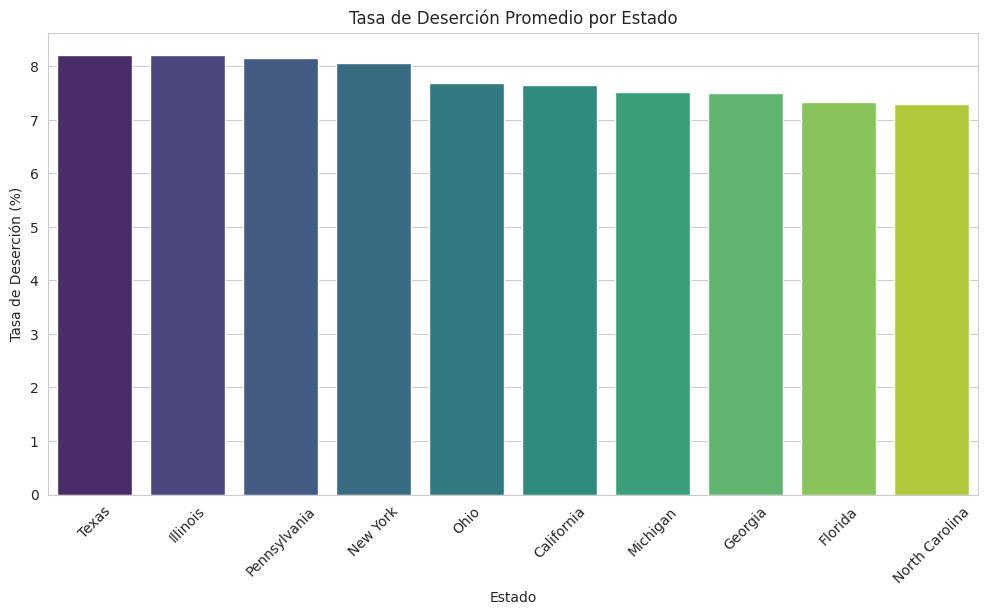

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x=desercion_por_estado.index, y=desercion_por_estado.values, palette="viridis")
plt.title('Tasa de Deserción Promedio por Estado')
plt.xlabel('Estado')
plt.ylabel('Tasa de Deserción (%)')
plt.xticks(rotation=45)
plt.show()

conclusion de la grafica

###**Hipótesis de correlación**

1.   Más financiamiento por estudiante se relaciona con un mejor puntaje en las pruebas.
2.   Una mayor accesibilidad a internet ayuda a los estudiantes a tener mejores puntajes en las pruebas.
3. Existe una relación entre la violencia familiar y la deserción escolar

In [ ]:
correlacion_financiamiento=df_inequality['financiamiento_por_estudiante_usd'].corr(df_inequality['promedio_puntaje_pruebas_pct'])
print(f"Correlación entre financiamiento y puntaje de prueba: {correlacion_financiamiento: .2f}")

correlacion_internet=df_inequality['acceso_internet_pct'].corr(df_inequality['promedio_puntaje_pruebas_pct'])
print(f"Correlación entre acceso a internet y puntaje de prueba: {correlacion_internet: .2f}")

Correlación entre financiamiento y puntaje de prueba:  0.02
Correlación entre acceso a internet y puntaje de prueba: -0.00


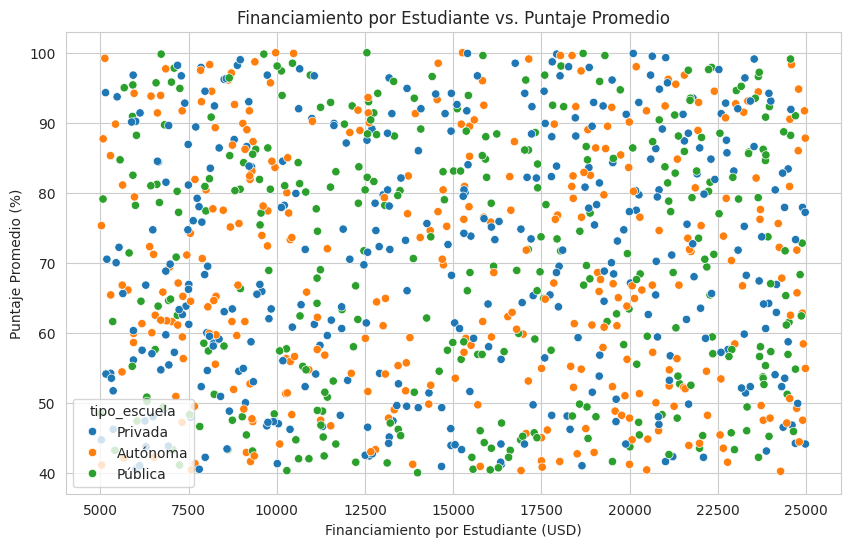

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='financiamiento_por_estudiante_usd', y='promedio_puntaje_pruebas_pct', hue='tipo_escuela', data=df_inequality)
plt.title('Financiamiento por Estudiante vs. Puntaje Promedio')
plt.xlabel('Financiamiento por Estudiante (USD)')
plt.ylabel('Puntaje Promedio (%)')
plt.show()

A partir del análisis de correlación se obtuvo un coeficiente de correlación de 0.02 y -0.0. Este valor indica una relación lineal prácticamente nula entre ambas variables. En otras palabras, no se evidencia una asociación significativa entre el nivel de inversión económica por estudiante, ni su acceso a internet y su rendimiento académico promedio. Este resultado sugiere que estas variables por sí solas, no explican las diferencias en el desempeño escolar, lo que podría deberse a varios factores: la existencia de relaciones no lineales, efectos contextuales como el entorno socioeconómico o la gestión escolar, o bien la presencia de otras variables mediadoras que no se están considerando directamente en este análisis.


Esta parte, busca encontrar coincidencias en aquellos registros con factores en común.

In [ ]:
contingencia = pd.crosstab(df_desercion['violencia_intrafamiliar'], df_desercion['deserción_escolar'])
contingencia

deserción_escolar,No,Sí
violencia_intrafamiliar,,
No,32,38
Sí,45,34


En realidad, los datos no son determinantes y podríamos deducir que se debe a nuestro corto dataset, pero podemos ver que hay una tasa más baja de deserción en aquellos casos en donde se sufre violencia intrafamiliar, pero como se menciona al principio no podemos determinar que exista una relación.

 ### **Rendimiento y Deserción por tipo de escuela**

 Compara el rendimiento académico y la deserción entre escuelas públicas, privadas y chárter.

> Las escuelas charter son similáres a las públicas, la diferencia radica en la toma de decisiónes de su contenido curricular



In [ ]:
promedios_por_tipo = df_inequality.groupby('tipo_escuela')[['promedio_puntaje_pruebas_pct', 'tasa_desercion_pct']].mean()
promedios_por_tipo.columns = ['Promedio Puntaje', 'Promedio Deserción']
promedios_por_tipo.index.name = 'Tipo de escuela'
print("Promedios por tipo de escuela:\n", promedios_por_tipo)

Promedios por tipo de escuela:
                  Promedio Puntaje  Promedio Deserción
Tipo de escuela                                      
Autónoma                69.069632            8.094693
Privada                 70.505634            7.760479
Pública                 70.391223            7.434984


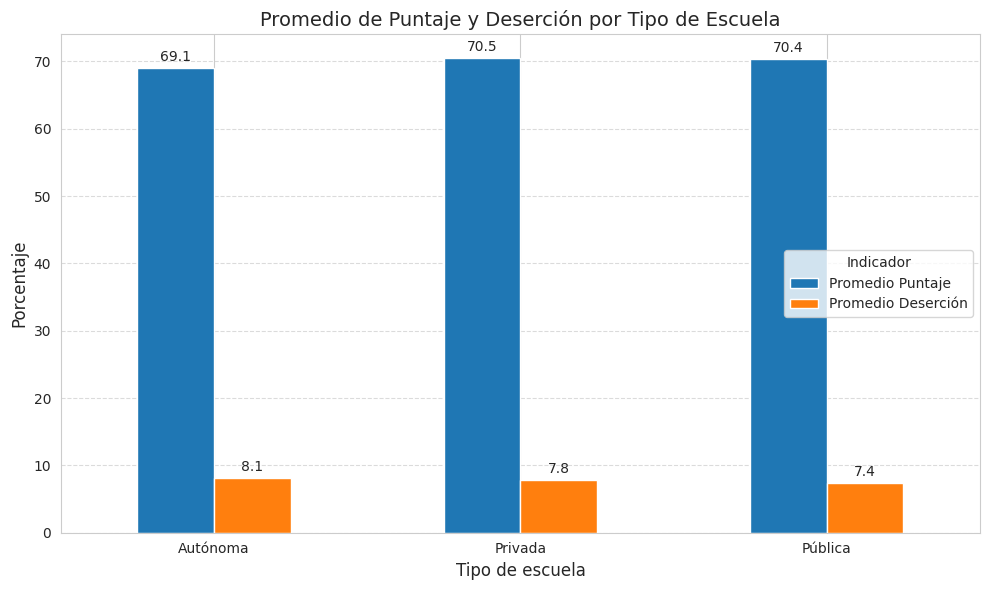

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
barras = promedios_por_tipo.plot(
    kind='bar',
    ax=ax,
    rot=0,  # Rotación de etiquetas del eje x
    color=['#1f77b4', '#ff7f0e']  # Colores personalizados (azul, naranja)
)

for contenedor in barras.containers:
    barras.bar_label(contenedor, fmt='%.1f', padding=3)
ax.set_title("Promedio de Puntaje y Deserción por Tipo de Escuela", fontsize=14)
ax.set_ylabel("Porcentaje", fontsize=12)
ax.set_xlabel("Tipo de escuela", fontsize=12)
ax.legend(title="Indicador")
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


**Distribucion promedio vs tipo escuela**

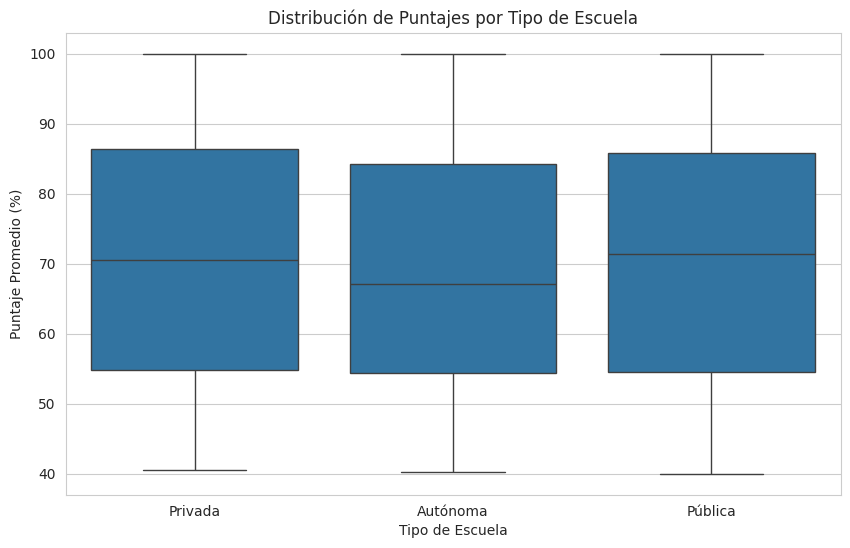

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='tipo_escuela', y='promedio_puntaje_pruebas_pct', data=df_inequality)
plt.title('Distribución de Puntajes por Tipo de Escuela')
plt.xlabel('Tipo de Escuela')
plt.ylabel('Puntaje Promedio (%)')
plt.show()

**Promedio maestros vs alumnos**


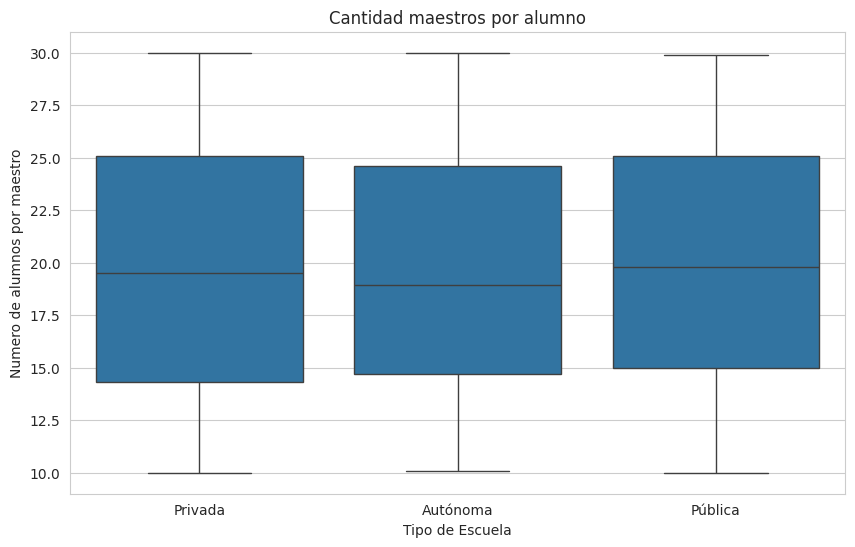

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='tipo_escuela', y='relacion_estudiante_docente', data=df_inequality)
plt.title('Cantidad maestros por alumno')
plt.xlabel('Tipo de Escuela')
plt.ylabel('Numero de alumnos por maestro')
plt.show()

**Promedio de deserción escolar según el nivel eductivo**

Muestra el promedio de la tasa de deserción según el nivel educativo: primaria, secundaria, superior.

In [ ]:
desercion_por_nivel = df_inequality.groupby('nivel_grado')['tasa_desercion_pct'].mean().sort_values(ascending=False)
print("Promedio de deserción escolar por nivel educativo:\n", desercion_por_nivel)


Promedio de deserción escolar por nivel educativo:
 nivel_grado
Primaria      8.094696
Superior      7.593152
Secundaria    7.591354
Name: tasa_desercion_pct, dtype: float64


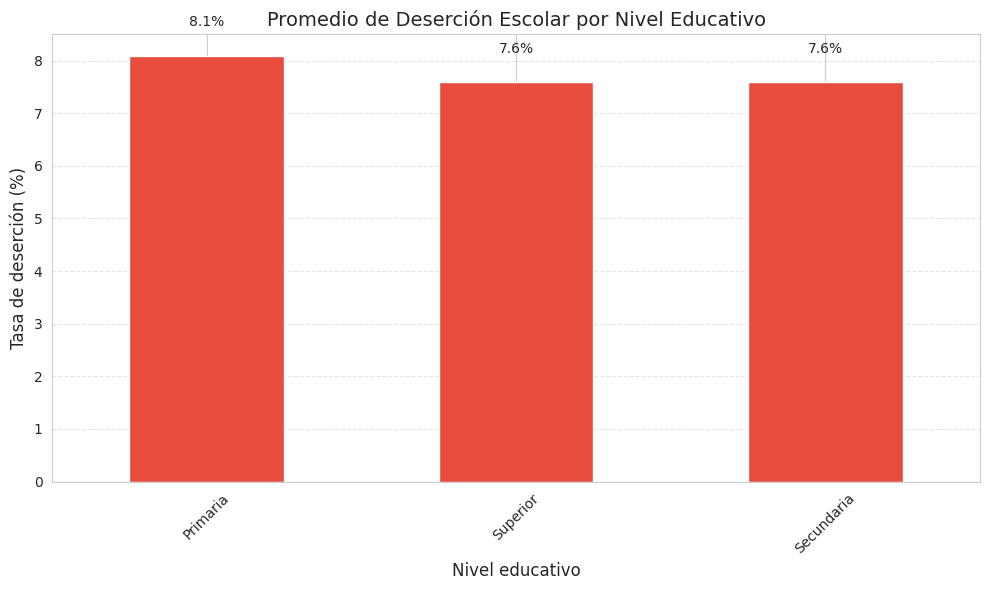

In [ ]:
plt.figure(figsize=(10, 6))
ax = desercion_por_nivel.plot(kind='bar', color='#e74c3c')
for i, valor in enumerate(desercion_por_nivel):
    ax.text(i, valor + 0.5, f'{valor:.1f}%', ha='center', va='bottom', fontsize=10)

plt.title("Promedio de Deserción Escolar por Nivel Educativo", fontsize=14)
plt.ylabel("Tasa de deserción (%)", fontsize=12)
plt.xlabel("Nivel educativo", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


**Distribución de la desercíon**

Distribución de la deserción y si hay escuelas con tasas extremadamente altas.

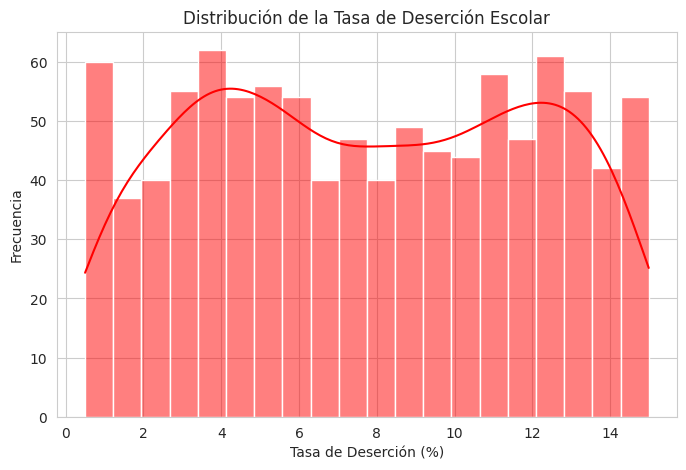

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df_inequality['tasa_desercion_pct'], bins=20, kde=True, color='red')
plt.title('Distribución de la Tasa de Deserción Escolar')
plt.xlabel('Tasa de Deserción (%)')
plt.ylabel('Frecuencia')
plt.show()

### Minorias

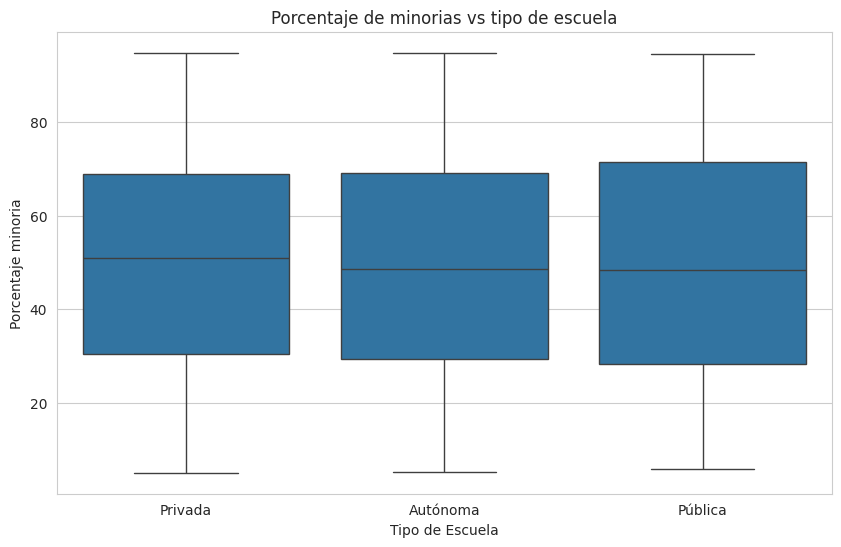

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='tipo_escuela', y='porcentaje_minorias', data=df_inequality)
plt.title('Porcentaje de minorias vs tipo de escuela')
plt.xlabel('Tipo de Escuela')
plt.ylabel('Porcentaje minoria')
plt.show()

##**Referencias**


---


Datos Obtenidos de https://www.kaggle.com/datasets/shamimhasan8/education-inequality-data

Datos Obtenidos de https:https://www.kaggle.com/datasets/uhbyguvyuhvb555/desercin-escolar-bogot-factores-de-riesgo

*    https://pandas.pydata.org/docs/index.html
*    https://matplotlib.org/stable/
*    https://seaborn.pydata.org/examples/index.html
